# Week 8 Assignment: Machine Learning

#### 1. Import libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.style.use('fivethirtyeight')
%matplotlib inline

In [39]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

#### 1.1 Load dataset

Imports the dataset

In [40]:
dataset = pd.read_csv('Churn.csv')

#### 1.2 Summarize the Dataset

Using this function will output the number of how many instances (rows) and how many attributes (columns) the data contains with the shape property.

In [41]:
dataset.shape

(667, 16)

Using this function will output the first 5 rows from the all the rows and columns in the imported dataset

In [42]:
dataset.head(5)

,Account length,Area code,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,117,408,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,65,415,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,161,415,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,111,415,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,49,510,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


Using the function can be use as a quick health check of data. Anaomalies can be easily seen such as minimum values when there shouldn't be. 

In [43]:
dataset.describe()

,Account length,Area code,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000
mean,102.841079,436.157421,180.948126,100.937031,30.761769,203.355322,100.476762,17.285262,199.685307,100.113943,8.985907,10.238381,4.527736,2.764948,1.563718
std,40.819480,41.783305,55.508628,20.396790,9.436463,49.719268,18.948262,4.226160,49.759931,20.172505,2.239429,2.807850,2.482442,0.758167,1.333357
min,1.000000,408.000000,25.900000,30.000000,4.400000,48.100000,37.000000,4.090000,23.200000,42.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,76.000000,408.000000,146.250000,87.500000,24.860000,171.050000,88.000000,14.540000,167.950000,86.000000,7.560000,8.600000,3.000000,2.320000,1.000000
50%,102.000000,415.000000,178.300000,101.000000,30.310000,203.700000,101.000000,17.310000,201.600000,100.000000,9.070000,10.500000,4.000000,2.840000,1.000000
75%,128.000000,415.000000,220.700000,115.000000,37.520000,236.450000,113.000000,20.095000,231.500000,113.500000,10.420000,12.050000,6.000000,3.255000,2.000000
max,232.000000,510.000000,334.300000,165.000000,56.830000,361.800000,168.000000,30.750000,367.700000,175.000000,16.550000,18.300000,18.000000,4.940000,8.000000


This functions counts the frequency of unique values in a series or dataframe column.  Specifically in this case it is used to see the churn rate. 
It can be assessed that the dataset is heavily imbalanced with the vast majority not churned. 

In [44]:
dataset['Churn'].value_counts()

Churn
False    572
True      95
Name: count, dtype: int64

These functions displays how many columns are categorical or numerical information

In [46]:
categorical = dataset.select_dtypes(include=[object])
print("Categorical Columns:",categorical.shape[1])

numerical = dataset.select_dtypes(exclude=[object])
print("Numerical Columns:",numerical.shape[1])

Categorical Columns: 0
Numerical Columns: 16


This function will bring back true is any of the data is missing (NaN/null) value anywhere (rows or columns). 

In [81]:
dataset.isnull().any().any()

np.False_

#### 1.3 Dividing data into features and labels

NOTE: As we can see dataset contains 3 columns: 'Total day minutes', 'Total eve minutes', 'Customer service calls'. Last column contains labels of samples. Firstly we need to split data into two arrays: X (features) and y (labels).  

Before training our predictive model, we need to separate our data into two distinct buckets. The first bucket (X) contains our Inputs these are 
the features or 'clues' we narrowed down, like total minutes and customer service calls. The second bucket (y) contains our Outputthe final answer 
we are trying to predict, which is whether the customer 'Churned' or not. Separating them like this teaches the algorithm to study the inputs 
and figure out how they lead to the final answer.

In [82]:
# After 4 iterations of testing narrowed down the required data to 
feature_columns = ['Total day minutes', 'Total eve minutes', 'Customer service calls']
X = dataset[feature_columns].values
y = dataset['Churn'].values

#### 1.4 Label encoding

NOTE: Machine learning models require numbers, not text, to do their math. In this step, we are using a tool called LabelEncoder to convert our target variable ('Churn') from True/False categories into 1s and 0s so the algorithm can process it. A customer who stayed (False) will correspond to 0, and a customer who left (True) will correspond to 1.

In [49]:
print(y)

[False  True  True False False False False  True False False False False
 False False  True False  True False False False False False False False
 False False False False False False False False False False False  True
 False False False False False  True False False False False False  True
 False False False False  True False False False  True False  True False
  True  True  True False False  True False False False False False False
 False False  True False False False False False False False False False
 False False False False False False False False False False False False
  True False  True False  True False False False False False False False
 False  True  True False False False  True  True False False False False
 False False False  True False False False False False False False False
  True False  True False False False False False False False False False
 False False False False False False False False False False  True  True
 False False False False False False False  True Fa

Transforms the True and False to corresponding 0 and 1 

In [50]:
le = LabelEncoder()
y = le.fit_transform(y)

In [51]:
# Labels after encoding
print(y)

[0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 1
 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 

#### 1.5 Spliting dataset into training set and test set

To avoid over-fitting, we will divide our dataset into training and test splits, which gives us a better idea as to how our algorithm performed during the testing phase. This way our algorithm is tested on un-seen data, as it would be in a production application.  This command splits the dataset into 80% train data and 20% test data. This means that out of total 150 records, the training set will contain 120 records and the test set contains 30 of those records.

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [53]:
X_train.shape

(533, 3)

#### 1.6 Feature Scaling
One might argue that the features values are basically the same order of magnitude (all in cm with average values between 1.2 cm and 5.84 cm), there is no need for feature scaling.  However, feature scaling is generally needed so we'll do that here.
Before making any actual predictions, it is (almost) always a good practice to scale the features so that all of them can be uniformly evaluated.

In [54]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
# What does our (X_train) dataset look like after Feature Scaling
print(X_train)

[[-0.10400168 -0.25404868  0.29660469]
 [-0.27362498  0.27987049  1.79509096]
 [ 1.77078217 -0.46761635  2.54433409]
 ...
 [ 0.22453187 -0.10092469 -1.20188157]
 [ 0.19060721  1.07772708 -0.45263844]
 [ 0.42807983 -0.96325453  1.04584782]]


It is important that you experiment with various aspects of any model.  For example, you might try increasing or decreasing test_size in train_test_split.  Or you might try running the model without using Feature Scaling and seeing how that impacts the results.

### 2. Data Visualization

In [90]:
dataset2 = dataset.filter(['Total day minutes','Total eve minutes','Customer service calls','Churn'], axis=1)

#### 2.1 Parallel Coordinates

Parallel coordinates is a plotting technique for plotting multivariate data. It allows one to see clusters in data and to estimate other statistics visually. Using parallel coordinates points are represented as connected line segments. Each vertical line represents one attribute. One set of connected line segments represents one data point. Points that tend to cluster will appear closer together.   

Think of this as mapping the 'highways' our customers travel. If you trace the teal lines (Churned), you can see if they group together and spike on specific axes. It visually proves that churn isn't random; churned customers share a distinct, repeatable pattern of behavior across multiple categories.  In this case when customers only reach up to a certain amount of minutes which are higher for total eve minutes.  

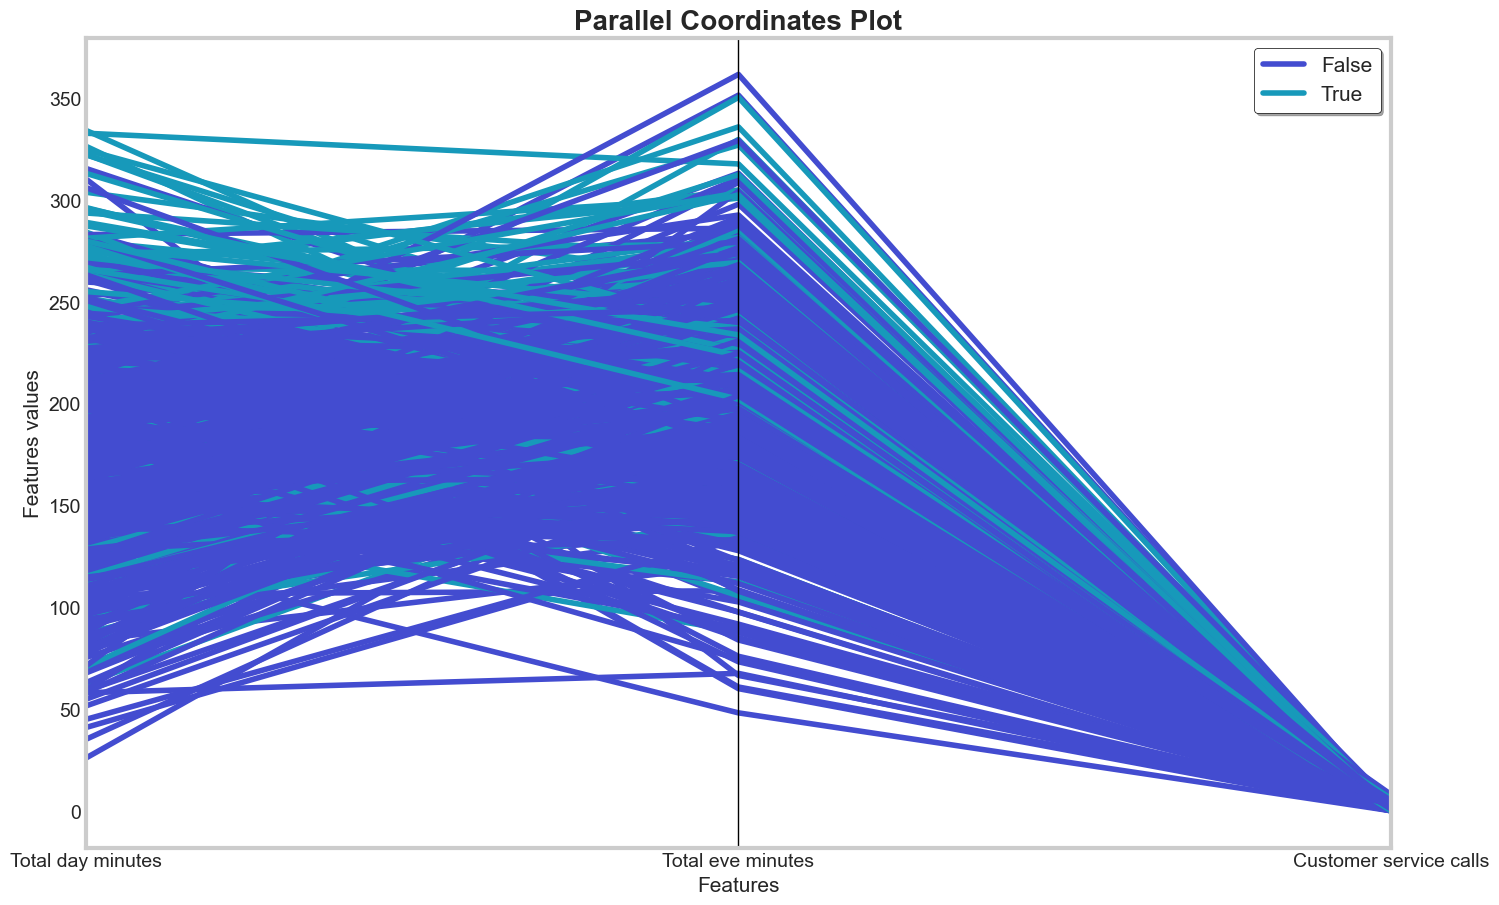

In [99]:
from pandas.plotting import parallel_coordinates
plt.figure(figsize=(15,10))
parallel_coordinates(dataset2, "Churn")
plt.title('Parallel Coordinates Plot', fontsize=20, fontweight='bold')
plt.xlabel('Features', fontsize=15)
plt.ylabel('Features values', fontsize=15)
plt.legend(loc=1, prop={'size': 15}, frameon=True,shadow=True, facecolor="white", edgecolor="black")
plt.show()

#### 2.2. Andrews Curves

Andrews curves allow one to plot multivariate data as a large number of curves that are created using the attributes of samples as coefficients for Fourier series. By coloring these curves differently for each class it is possible to visualize data clustering. Curves belonging to samples of the same class will usually be closer together and form larger structures.

This acts like a behavioral fingerprint. If the wavy lines for the churned customers group together in a completely different pattern than the non-churned customers, it confirms that our churners aren't just average users having a bad day they represent a fundamentally different type of user profile. This tells much of the same story that the minutes are reaching a peak and a centered around a certain point.  

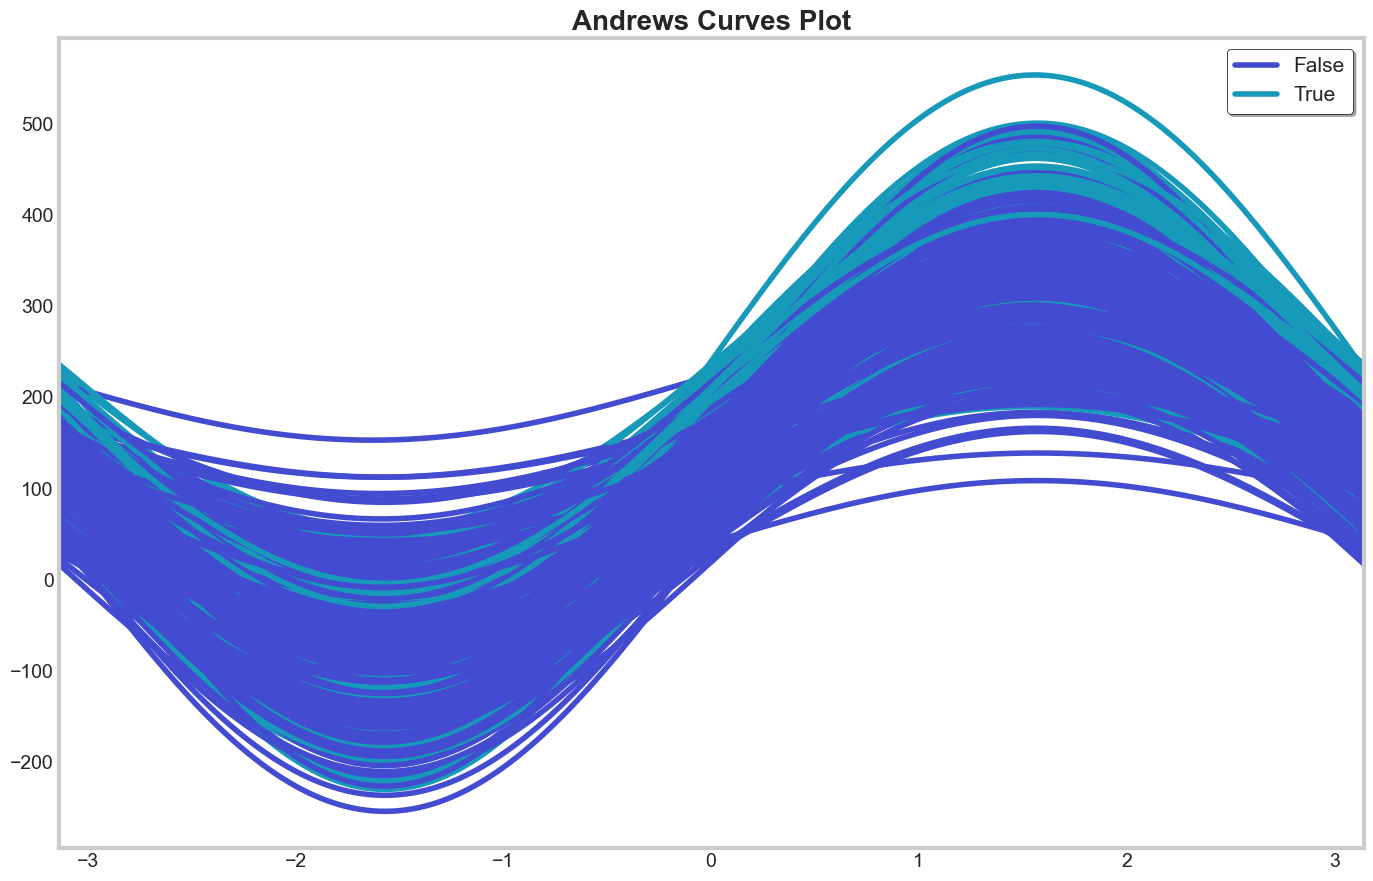

In [93]:
from pandas.plotting import andrews_curves
plt.figure(figsize=(15,10))
andrews_curves(dataset2, "Churn")
plt.title('Andrews Curves Plot', fontsize=20, fontweight='bold')
plt.legend(loc=1, prop={'size': 15}, frameon=True,shadow=True, facecolor="white", edgecolor="black")
plt.show()

#### 2.3 Pairplot

Pairwise is useful when you want to visualize the distribution of a variable or the relationship between multiple variables separately within subsets of your dataset.  If you have more or fewer than 3 labels (target variables), you will need to adjust markers= (add or remove specific markers) or simply remove it and accept the default.

This is our rapid-fire matchmaking grid. By looking at all possible combinations of our data at once, we can quickly scan for which specific pair of metrics creates the clearest separation between the blue dots (stayed) and orange dots (left). It is the exact tool we used to figure out which features were worth focusing on.  It can be clearly seen that there is a central point at around 200 minutes for both day and eve minutes.  

<Figure size 640x480 with 0 Axes>

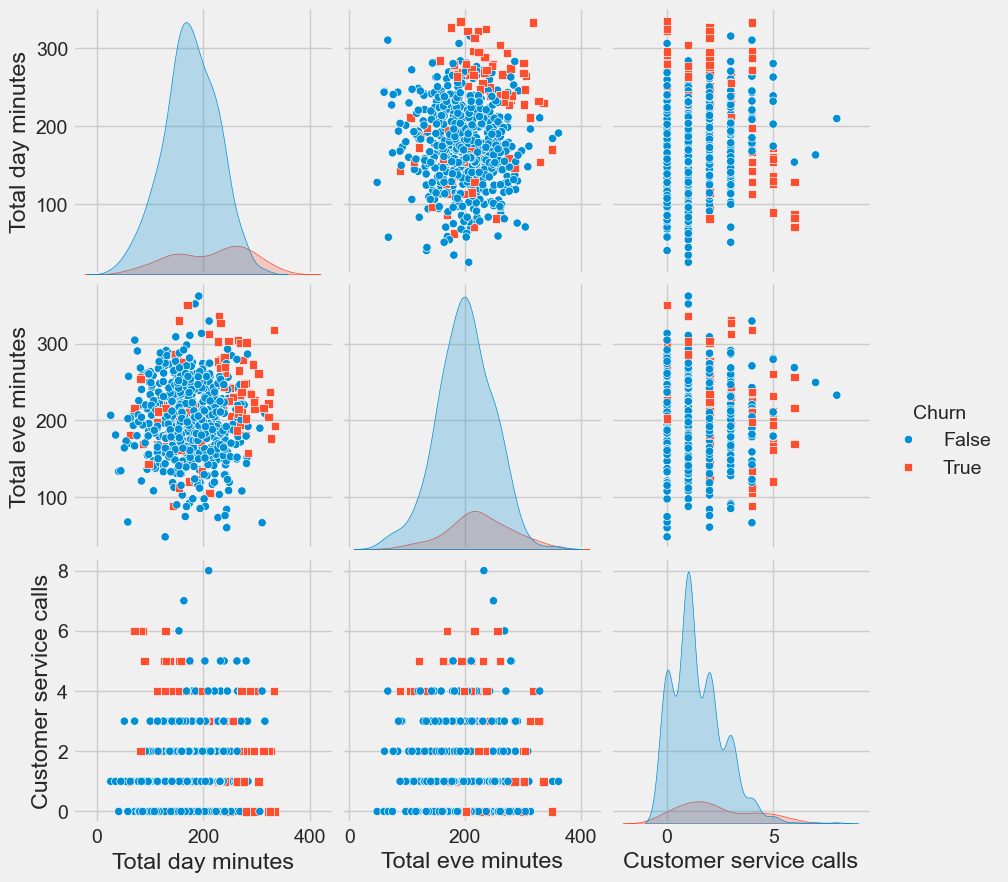

In [59]:
plt.figure()
sns.pairplot(dataset2, hue="Churn", height=3, markers=["o", "s"])
plt.show()

#### 2.4 Boxplots

It shows the statistical spread of the data, highlighting the median (the line in the middle) and the bulk of where the normal data lives (the box), while flagging extreme outliers (the dots outside the box).

#### Assessment

Averages can be highly deceptive if one extreme customer skews the math. Boxplots show us the typical reality. If the entire 'box' for churned customers sits noticeably higher on the 'Customer Service Calls' chart than the non-churned customers' box, it proves our average churner is demonstrably unhappier than our average non-churned customer.  

The boxplots reveal a clear behavioral difference in how minutes are consumed. For total day minutes, the average non-churned customer uses about 175 minutes, while the average churned customer uses significantly more, at around 245 minutes. Interestingly, this trend flips at night: non-churned customers actually show slightly higher nighttime usage than daytime usage. This suggests there may be a restriction on daytime minutes (such as a limited 'free nights and weekends' plan). The customers who are forced to make heavy daytime calls are likely racking up massive overage fees, which ultimately drives them to cancel their service.

<Figure size 640x480 with 0 Axes>

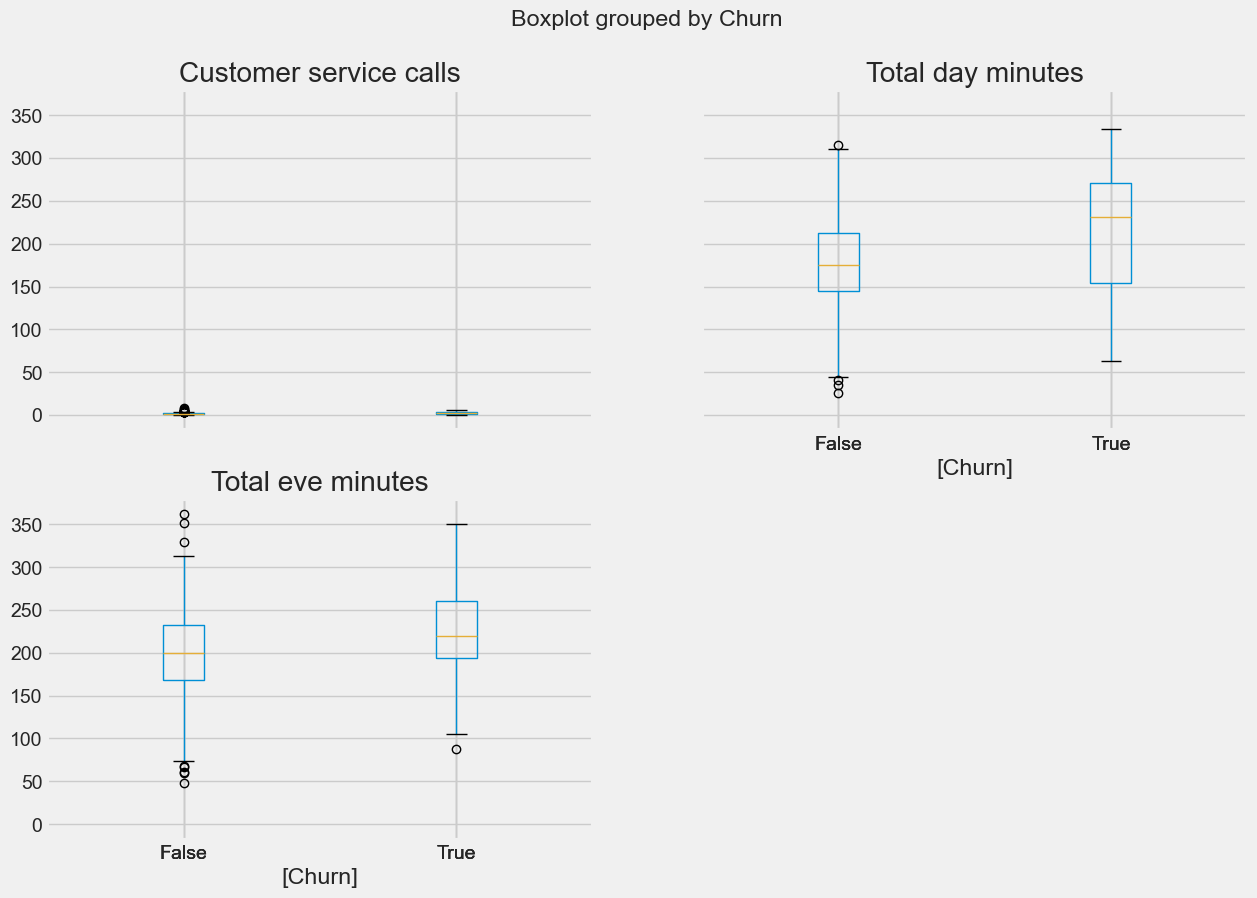

In [60]:
plt.figure()
dataset2.boxplot(by="Churn", figsize=(15, 10))
plt.show()

#### 2.5 Correlation Heatmap

It calculates how closely related different columns are, coloring the grid based on the strength of the mathematical link.

This is our 'redundancy detector.' For example, 'Day Minutes' and 'Day Charge' will light up perfectly correlated because one is literally just a calculation of the other. This chart tells us exactly which repetitive data we need to delete so we don't confuse our algorithm with duplicate 'noise' 

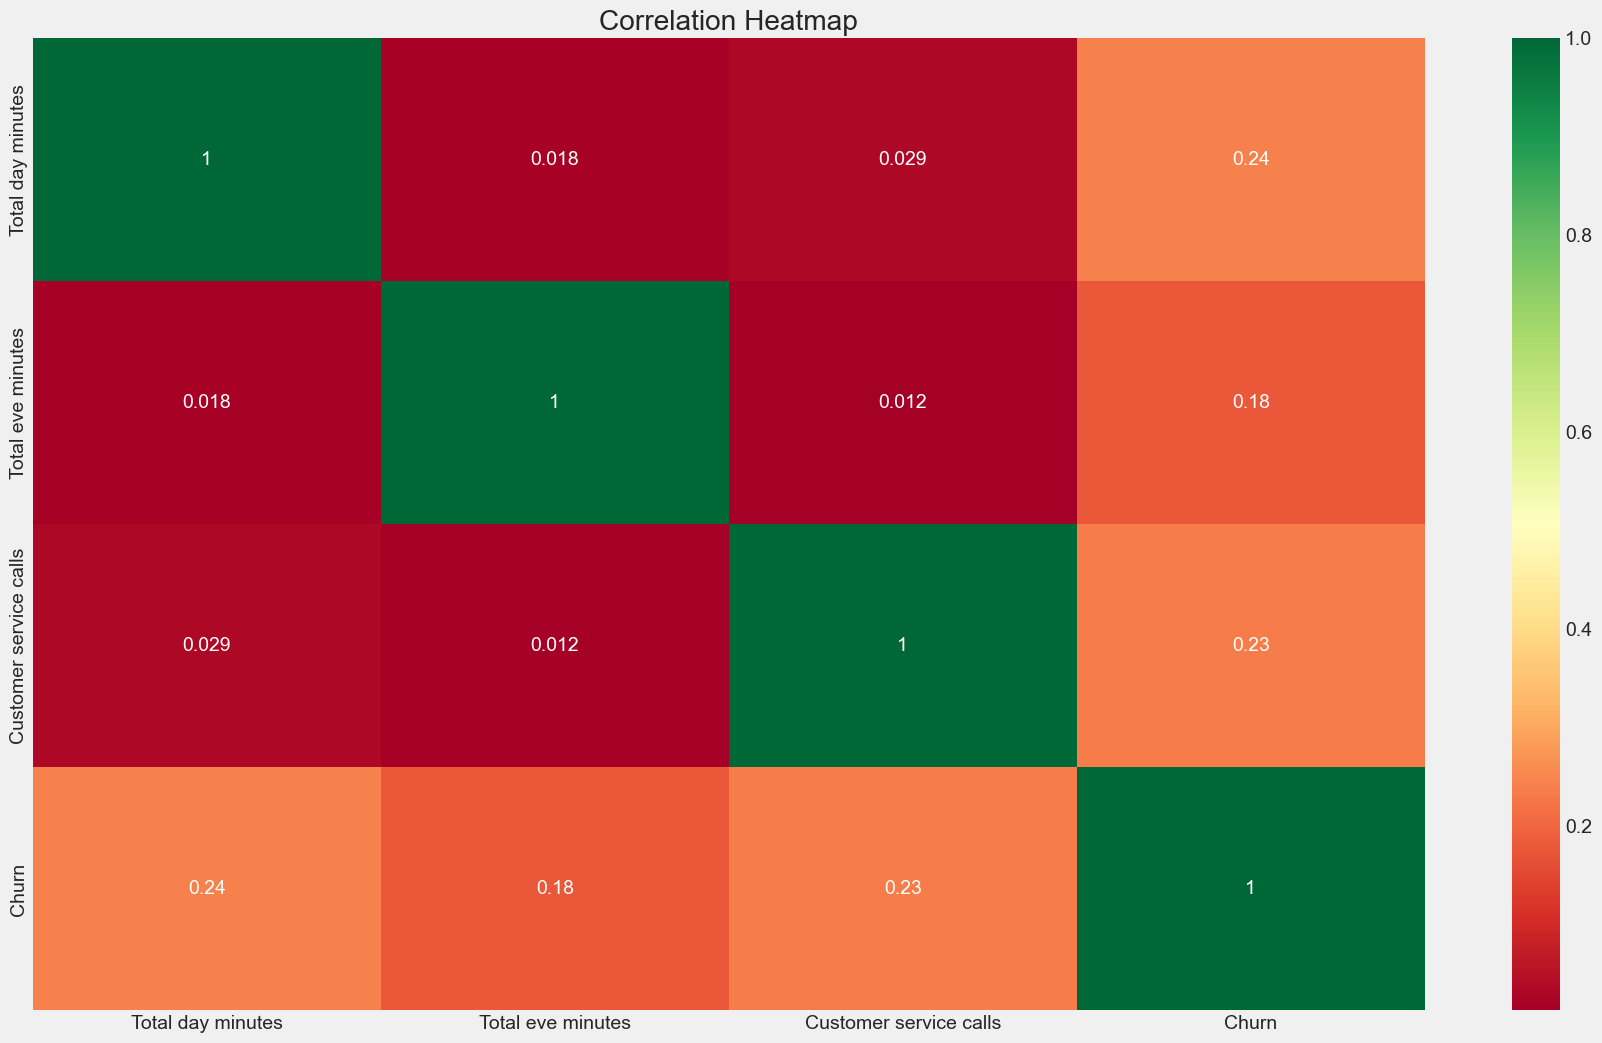

In [61]:
plt.figure(figsize=(20,12))
#draws heatmap with input as the correlation matrix calculted by(data.corr())
sns.heatmap(dataset2.corr(numeric_only=True).abs(), annot=True, cmap='RdYlGn')
plt.title('Correlation Heatmap')
plt.show()

#### 2.6 Histogram Overlaid with a Scatter Chart

Creates a topological "density map" showing where the vast majority of normal customer behavior is concentrated (the background heat map), while simultaneously plotting the exact individual positions of loyal versus defecting customers on top.

#### Assessment

This is our 'churn danger zone' map. By plotting Day Minutes against Evening Minutes, the background heatmap shows us exactly what an 'average' customer looks like. More importantly, the red X's (churned customers) clearly break away from the main cluster and thicken as evening usage crosses the 250-minute mark. This visually pinpoints exactly where we are losing our heaviest, most valuable users likely due to 'bill shock' from overage fees on limited plans.  However, a fundamental rule of data science is that correlation does not equal causation. 

By correlating our boxplot spread with our density map, we can build a highly specific profile of our highest-risk customers. The boxplots reveal a clear behavioral split: non-churned customers tend to wait until nighttime to make heavy calls, while churned customers are making significantly more daytime calls (averaging 245 minutes compared to the non-churned average of 175).

#### Hypothesis

These high-risk customers are likely on restrictive plans (such as "Free Nights and Weekends"). When their schedule forces them to consistently exceed their daytime or evening allowances (pushing past that 250-minute mark), they get hit with massive overage fees ("bill shock") and cancel their service. While we must remember that correlation does not equal causation without auditing actual billing records, this gives our retention team a precise, data-backed metric to act on: proactively offer unlimited upgrades to any customer approaching 250 restricted minutes.  To undestand more incorporate outside data showing the exact timestamps of these calls to map them against the provider's specific day/night billing windows.  

### Result

Even without auditing those precise timestamps or billing records, this model gives our retention team a highly accurate, data-backed metric to act on immediately: proactively offer unlimited upgrades to any customer approaching 250 restricted minutes.

In [104]:
import plotly.graph_objects as go
import numpy as np

non_churned = dataset2[dataset2['Churn'] == False]
churned = dataset2[dataset2['Churn'] == True]

x0 = non_churned['Total day minutes']
y0 = non_churned['Total eve minutes']

x1 = churned['Total day minutes']
y1 = churned['Total eve minutes']

x_all = dataset2['Total day minutes']
y_all = dataset2['Total eve minutes']

fig = go.Figure()

fig.add_trace(go.Histogram2d(
    x=x_all,
    y=y_all,
    colorscale='YlGnBu',
    nbinsx=20,
    nbinsy=20,
    zauto=True, 
))

fig.add_trace(go.Scatter(
    x=x0,
    y=y0,
    mode='markers',
    name='Non-churned', 
    marker=dict(
        symbol='circle',
        opacity=0.6,
        color='white',
        size=7, 
        line=dict(width=1, color='black'),
    )
))

fig.add_trace(go.Scatter(
    x=x1,
    y=y1,
    mode='markers',
    name='Churned', 
    marker=dict(
        symbol='x',
        opacity=0.9,
        color='red',
        size=7, 
        line=dict(width=2, color='darkred'),
    )
))

fig.update_layout(
    title='Customer Density: Day Minutes vs. Eve Minutes',
    xaxis=dict(title='Total Day Minutes', ticks='', showgrid=False, zeroline=False),
    yaxis=dict(title='Total Eve Minutes', ticks='', showgrid=False, zeroline=False),
    autosize=False,
    height=600,
    width=800,
    hovermode='closest',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show(renderer="iframe")

### 3. Using KNN for classification

To predict if a new customer will leave, our algorithm uses the 'birds of a feather flock together' approach. If we map a new customer on our graph, the algorithm looks at their closest 'neighbors.' If the majority of a customer's closest neighbors are people who previously canceled their service, the algorithm predicts this new customer is a high flight risk.

In [106]:
# Fitting clasifier to the Training set
# Loading libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score

# Instantiate learning model (k = 3)
classifier = KNeighborsClassifier(n_neighbors=17)

# Fitting the model
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

#### 3.2 Evaluating predictions

In [107]:
confusion_matrix(y_test,y_pred)

array([[114,   1],
       [ 14,   5]])

This is our scorecard. Overall, our model correctly predicted customer behavior 88.8% of the time. The 'Confusion Matrix' breaks down exactly where we succeeded and where we made errors. Out of 134 test customers, we successfully identified 114 who stayed and 5 who left. We only had 1 'false alarm' (predicting someone would leave when they stayed), but we did miss 14 churners. This tells the business that while our model is highly accurate overall, it is slightly conservative when flagging flight risks.

Below pandas has a built-in functionality that makes the confusion matrix slightly more readable.

In [108]:
pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,False,True,All
True,,,
False,114,1,115
True,14,5,19
All,128,6,134


A **Classification Report** is often used in tandem with the confusion matrix.  

*   **Recall** refers to the model's ability to correctly identify the result.  Note recall for Iris-virginica (2) is 80%.  Recall for Iris-versicolor (1) is 100% because the model identified ALL Iris-versicolor instances.
*   **Precision** reflects successful identification within those identified.  Note Iris-virginica (2) precision is 100%, because of the 8 instances identified as Iris-virginica, all were correct.  Precision for Iris-versicolor (1) is 83% which corresponds to 10 correct of 12 predictions.
*   **F1-score** is a weighted average of Recall and Precision.
*   **Accuracy** represents overall accuracy of the model.






In [109]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.89      0.99      0.94       115
        True       0.83      0.26      0.40        19

    accuracy                           0.89       134
   macro avg       0.86      0.63      0.67       134
weighted avg       0.88      0.89      0.86       134



Calculating model accuracy

In [110]:
accuracy = accuracy_score(y_test, y_pred)*100
print('Accuracy of our model is equal ' + str(round(accuracy, 2)) + ' %.')

Accuracy of our model is equal 88.81 %.


#### 3.3 Using cross-validation for parameter tuning

We don't want to just guess how many 'neighbors' the algorithm should look at to make its decision. If it looks at too few (like 1 or 2), it becomes overly sensitive to weird outliers. If it looks at too many (like 100), it blends everyone together and loses accuracy. By running the model through a rigorous testing process called Cross-Validation, we mathematically proved that checking exactly 17 neighbors provides the absolute 'sweet spot' for the highest predictive accuracy.

Method 1

In [67]:
# creating list of K for KNN
k_list = list(range(1,50,2))
# creating list of cv scores
cv_scores = []

# perform 10-fold cross validation
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

<Figure size 640x480 with 0 Axes>

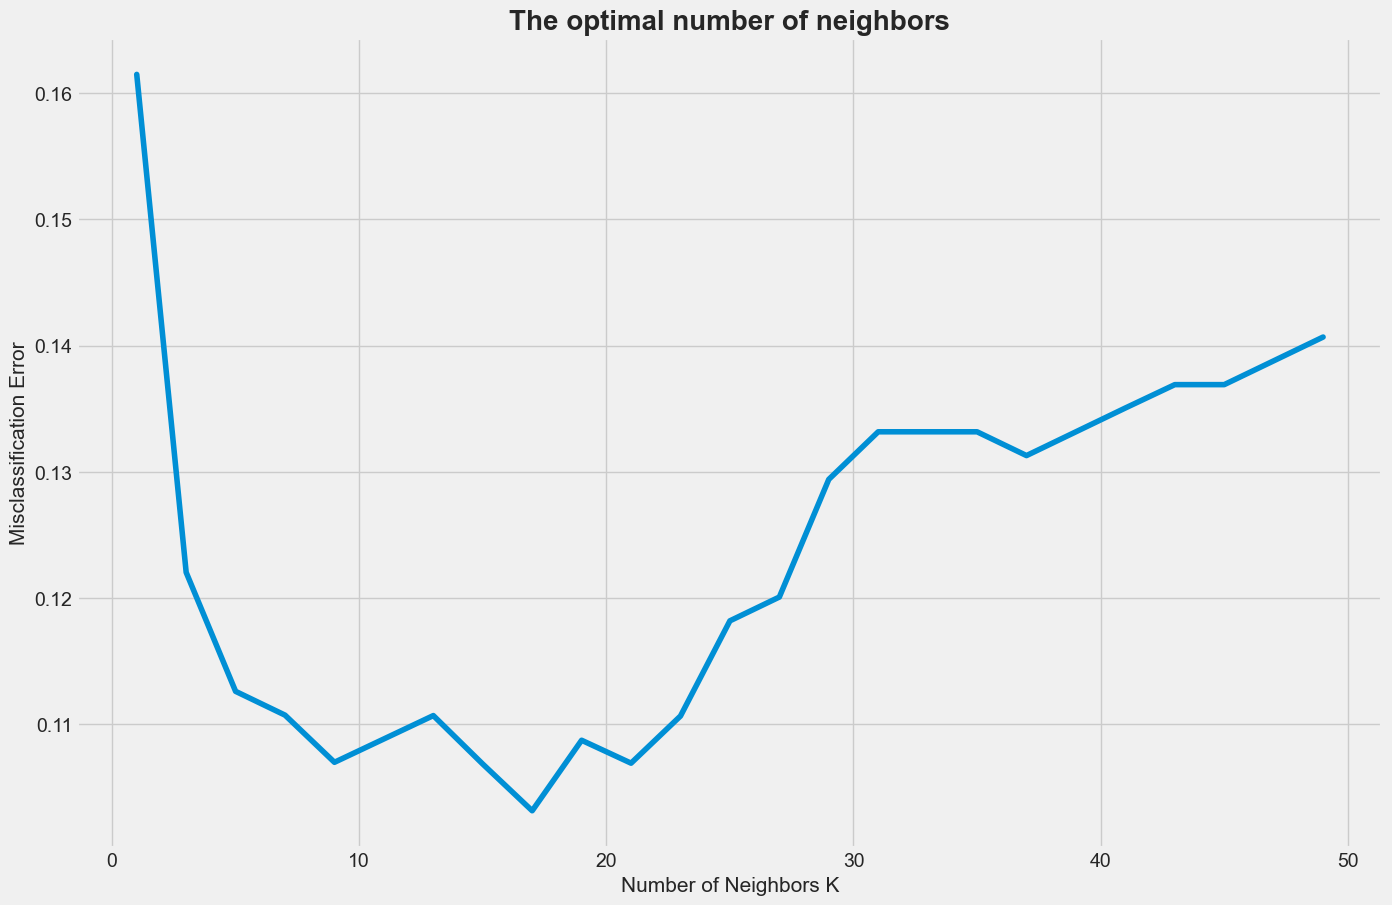

In [68]:
# changing to misclassification error
MSE = [1 - x for x in cv_scores]

plt.figure()
plt.figure(figsize=(15,10))
plt.title('The optimal number of neighbors', fontsize=20, fontweight='bold')
plt.xlabel('Number of Neighbors K', fontsize=15)
plt.ylabel('Misclassification Error', fontsize=15)
sns.set_style("whitegrid")
plt.plot(k_list, MSE)

plt.show()

In [69]:
# finding best k
best_k = k_list[MSE.index(min(MSE))]
print("The optimal number of neighbors is %d." % best_k)

The optimal number of neighbors is 17.


Method 2

In [70]:
error_rate = []

for i in range(1,50):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error_rate.append(np.mean(pred != y_test))

Text(0, 0.5, 'Mean Error')

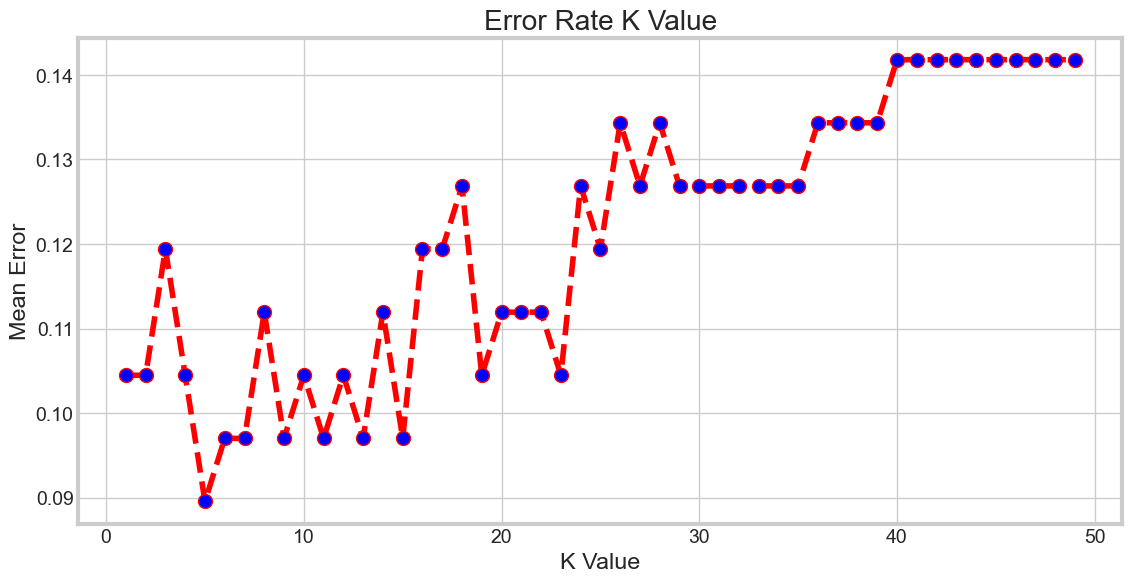

In [71]:
plt.figure(figsize=(12, 6))
plt.plot(range(1,50), error_rate, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

**GridSearch Cross-Validation**

Normally in machine learning, the data set is divided into training and testing sets.  We use the training data to train the model and the testing set to evaluate performance. This may lead to problems in variance, however, which is when different combinations of training/testing sets lead to different results.

For this reason, we perform cross-validation.  GridSearchCV is one form of cross-validation provided by Scikit Learn.  We're basically going to send a dictionary of parameters, defined below as param_grid, defining our model (n_neighbors) and sending various values for K, number of neighbors.  Then we re-run the model with a subsets of the data.  In the case below, cv=5 means that we are conducting a 5-fold cross validation.  We will create 5 subsets of the data.  In the first iteration (or 'fold'), sets 1-4 are used as the training set and set 5 as testing.  In the second fold, sets 1-3 and 5 might be used for training and set 4 for testing, and so on.  At any rate, rotating through various sets helps us to conduct cross-validation and reduce variance.

In [72]:
#import GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors':np.arange(1,50)}
knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=5)
knn_cv.fit(X,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 1, 2..., 47, 48, 49])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

In [73]:
#print the best score obtained during GridSearchCV
knn_cv.best_score_

np.float64(0.8755246324767141)

In [74]:
# and the optimal number of neighbors (note different techniques may identify different results for 'optimal number')
knn_cv.best_params_

{'n_neighbors': np.int64(46)}